# 08 Inference Model

This notebook performs manual inference using the current optimized artifacts.

Inference flow is now aligned with the codebase:

- load scaler, label encoder, `MAX_FRAMES`, and the trained checkpoint
- preprocess incoming audio with the same normalization path as the project
- apply optional noise reduction only if requested by the current config or the caller
- extract features with `src.feature_extraction.extract_sequence_features`
- scale, pad/truncate, and predict
- support both single-file and batch inference
        

In [1]:
from pathlib import Path
import pickle
import sys
import warnings

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Audio, display
from tensorflow import keras


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing config.yaml and src/")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluate import EMOTION_NAMES, load_model_with_fallback
from src.feature_extraction import extract_sequence_features, get_feature_dim, pad_or_truncate
from src.model import build_bilstm_model
from src.preprocessing import normalize_audio, reduce_noise
from src.utils import load_config

warnings.filterwarnings("ignore")

config = load_config(PROJECT_ROOT / "config.yaml")
paths = config["paths"]
preproc_cfg = config["preprocessing"]
feat_cfg = config["features"]

features_dir = Path(paths["features_dir"])
models_dir = Path(paths["models_dir"])
outputs_dir = Path(paths["outputs_dir"])
outputs_dir.mkdir(parents=True, exist_ok=True)

with open(features_dir / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(features_dir / "label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

max_frames = int(np.load(features_dir / "max_frames.npy").squeeze())
feature_dim = get_feature_dim(feat_cfg)

print("max_frames:", max_frames)
print("feature_dim:", feature_dim)
print("Label classes:", list(label_encoder.classes_))
        

max_frames: 119
feature_dim: 120
Label classes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05')]


In [2]:
def load_runtime_model(config, input_shape):
    model_keras_path = Path(config["paths"]["models_dir"]) / "best_model.keras"
    model_h5_path = Path(config["paths"]["models_dir"]) / "best_model.h5"

    if model_keras_path.exists():
        return keras.models.load_model(model_keras_path, compile=False)

    if model_h5_path.exists():
        try:
            return load_model_with_fallback(model_h5_path)
        except Exception:
            model = build_bilstm_model(input_shape=input_shape, config=config)
            model.load_weights(model_h5_path)
            return model

    raise FileNotFoundError("No model checkpoint found in models/")


model = load_runtime_model(config, input_shape=(max_frames, feature_dim))
print("Loaded model:", model.name)
        


Loaded model: SER_BiLSTM


In [3]:
def preprocess_audio_for_model(
    audio_path,
    config,
    scaler,
    max_frames,
    apply_noise_reduction=None,
):
    if apply_noise_reduction is None:
        apply_noise_reduction = bool(config["preprocessing"].get("apply_noise_reduction", False))

    audio, sr = normalize_audio(
        audio_path,
        target_sr=int(config["preprocessing"]["target_sr"]),
        trim_enabled=bool(config["preprocessing"].get("trim_silence", False)),
        trim_top_db=float(config["preprocessing"].get("trim_top_db", 35.0)),
        trim_frame_length=int(config["preprocessing"].get("trim_frame_length", 2048)),
        trim_hop_length=int(config["preprocessing"].get("trim_hop_length", 512)),
    )

    if apply_noise_reduction:
        audio = reduce_noise(
            audio,
            sr,
            freq_range=tuple(config["preprocessing"].get("noise_freq_range", [300, 3400])),
        )

    feats = extract_sequence_features(audio=audio, cfg=config["features"], sr=sr)
    feats = scaler.transform(feats.astype(np.float32))
    feats = pad_or_truncate(feats, max_frames=max_frames)

    if feats.shape[1] != get_feature_dim(config["features"]):
        raise RuntimeError(
            f"Feature width mismatch: expected {get_feature_dim(config['features'])}, got {feats.shape[1]}"
        )

    return feats[np.newaxis, ...].astype(np.float32)


def predict_emotion(audio_path, top_k=5, apply_noise_reduction=None):
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio path not found: {audio_path}")

    x = preprocess_audio_for_model(
        audio_path=audio_path,
        config=config,
        scaler=scaler,
        max_frames=max_frames,
        apply_noise_reduction=apply_noise_reduction,
    )
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_code = str(label_encoder.inverse_transform([pred_idx])[0])
    pred_name = EMOTION_NAMES[pred_idx]

    ranking = np.argsort(probs)[::-1][:top_k]
    top_rows = []
    for idx in ranking:
        code = str(label_encoder.inverse_transform([int(idx)])[0])
        top_rows.append(
            {
                "emotion_index": int(idx),
                "emotion_code": code,
                "emotion_name": EMOTION_NAMES[int(idx)],
                "probability": float(probs[idx]),
            }
        )

    return {
        "file_path": str(audio_path),
        "predicted_index": pred_idx,
        "predicted_code": pred_code,
        "predicted_name": pred_name,
        "confidence": float(probs[pred_idx]),
        "probabilities": probs,
        "top_k": pd.DataFrame(top_rows),
    }


def plot_prediction(result):
    plot_df = pd.DataFrame(
        {
            "emotion": EMOTION_NAMES,
            "probability": result["probabilities"],
        }
    ).sort_values("probability", ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_df, x="emotion", y="probability", palette="viridis")
    plt.ylim(0, 1)
    plt.title(f"Prediction: {result['predicted_name']} ({result['confidence']:.4f})")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
        

Default example audio: D:\Skripsi\Testing\Model_SERv4\processed_data\test\03-01-01-01.wav


,emotion_index,emotion_code,emotion_name,probability
0,0,01,Netral,0.988164
1,3,04,Jijik,0.004468
2,4,05,Kecewa,0.004193
3,1,02,Senang,0.002163
4,2,03,Terkejut,0.001012


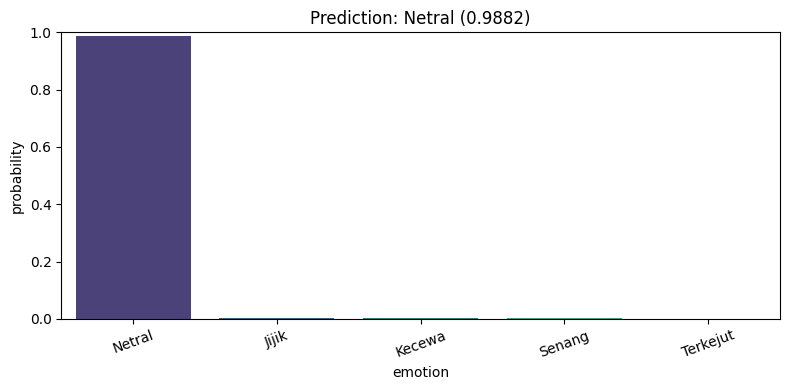

In [4]:
candidate_dirs = [
    Path(config["paths"]["processed_data_dir"]) / "test",
    Path(config["paths"]["processed_data_dir"]) / "validation",
    Path(config["paths"]["data_dir"]) / "Actor_01",
]

default_audio = None
for folder in candidate_dirs:
    wavs = sorted(folder.glob("*.wav")) if folder.exists() else []
    if wavs:
        default_audio = wavs[0]
        break

if default_audio is None:
    raise RuntimeError("No example audio found. Please provide a valid .wav path manually.")

print("Default example audio:", default_audio)
example_result = predict_emotion(default_audio, top_k=5)
display(example_result["top_k"])
plot_prediction(example_result)
display(Audio(str(default_audio)))
        

Predicted: Netral (0.9882)


,emotion_index,emotion_code,emotion_name,probability
0,0,01,Netral,0.988164
1,3,04,Jijik,0.004468
2,4,05,Kecewa,0.004193
3,1,02,Senang,0.002163
4,2,03,Terkejut,0.001012


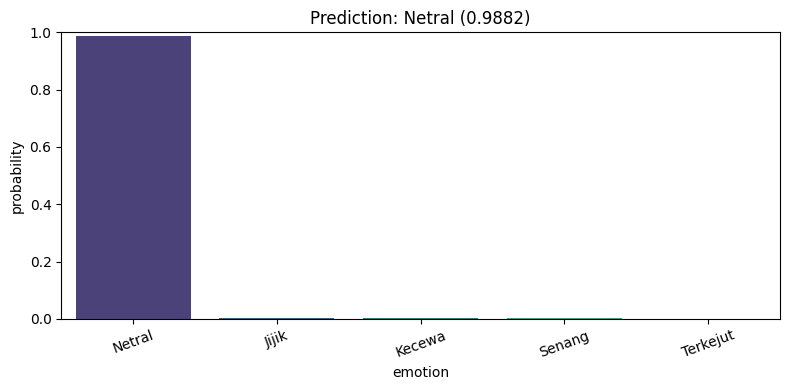

In [5]:
AUDIO_PATH = default_audio  # replace with your own .wav path if needed
APPLY_NOISE_REDUCTION = None  # None -> follow config; True/False -> override

manual_result = predict_emotion(AUDIO_PATH, top_k=5, apply_noise_reduction=APPLY_NOISE_REDUCTION)
print("Predicted:", manual_result["predicted_name"], f"({manual_result['confidence']:.4f})")
display(manual_result["top_k"])
plot_prediction(manual_result)
        

In [6]:
def batch_inference(input_path, recursive=True, apply_noise_reduction=None, save_csv=None):
    input_path = Path(input_path)

    if input_path.is_file():
        wav_files = [input_path] if input_path.suffix.lower() == ".wav" else []
    elif input_path.is_dir():
        pattern = "**/*.wav" if recursive else "*.wav"
        wav_files = sorted(input_path.glob(pattern))
    else:
        raise FileNotFoundError(f"Input path not found: {input_path}")

    if not wav_files:
        raise RuntimeError("No .wav files found for batch inference.")

    rows = []
    for wav_path in wav_files:
        row = {"file_path": str(wav_path)}
        try:
            result = predict_emotion(wav_path, top_k=5, apply_noise_reduction=apply_noise_reduction)
            row["predicted_code"] = result["predicted_code"]
            row["predicted_name"] = result["predicted_name"]
            row["confidence"] = result["confidence"]

            for idx, code in enumerate(label_encoder.classes_):
                row[f"prob_{str(code)}"] = float(result["probabilities"][idx])

            parts = wav_path.stem.split("-")
            if len(parts) == 4 and parts[1] in set(label_encoder.classes_):
                true_idx = int(label_encoder.transform([parts[1]])[0])
                row["true_code"] = parts[1]
                row["true_name"] = EMOTION_NAMES[true_idx]
                row["is_correct"] = int(parts[1] == row["predicted_code"])
            else:
                row["true_code"] = None
                row["true_name"] = None
                row["is_correct"] = None
        except Exception as exc:
            row["error"] = str(exc)
        rows.append(row)

    df = pd.DataFrame(rows)
    if save_csv is not None:
        save_csv = Path(save_csv)
        save_csv.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_csv, index=False)
        print("Saved:", save_csv)
    return df
        

In [7]:
BATCH_INPUT = Path(config["paths"]["processed_data_dir"]) / "test"
BATCH_OUTPUT = Path(config["paths"]["outputs_dir"]) / "inference_results.csv"

batch_df = batch_inference(
    input_path=BATCH_INPUT,
    recursive=True,
    apply_noise_reduction=None,
    save_csv=BATCH_OUTPUT,
)

display(batch_df.head(10))
if "is_correct" in batch_df.columns and batch_df["is_correct"].notna().any():
    valid = batch_df.dropna(subset=["is_correct"])
    print(f"Batch accuracy from filename-derived labels: {valid['is_correct'].mean():.4f}")
        

Saved: D:\Skripsi\Testing\Model_SERv4\outputs\inference_results.csv


,file_path,predicted_code,predicted_name,confidence,prob_01,prob_02,prob_03,prob_04,prob_05,true_code,true_name,is_correct
0,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.988164,0.988164,0.002163,0.001012,0.004468,0.004193,01,Netral,1
1,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.992317,0.992317,0.001354,0.000612,0.002845,0.002872,01,Netral,1
2,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.986506,0.986506,0.002842,0.001138,0.005118,0.004396,01,Netral,1
3,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.971709,0.971709,0.004133,0.002096,0.010958,0.011105,01,Netral,1
4,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.989242,0.989242,0.001581,0.000827,0.003946,0.004404,01,Netral,1
5,D:\Skripsi\Testing\Model_SERv4\processed_data\...,01,Netral,0.983202,0.983202,0.002506,0.001314,0.006206,0.006772,01,Netral,1
6,D:\Skripsi\Testing\Model_SERv4\processed_data\...,02,Senang,0.979617,0.001943,0.979617,0.014932,0.002780,0.000727,02,Senang,1
7,D:\Skripsi\Testing\Model_SERv4\processed_data\...,02,Senang,0.965194,0.002421,0.965194,0.027761,0.003550,0.001074,02,Senang,1
8,D:\Skripsi\Testing\Model_SERv4\processed_data\...,02,Senang,0.980319,0.002125,0.980319,0.013741,0.003045,0.000770,02,Senang,1
9,D:\Skripsi\Testing\Model_SERv4\processed_data\...,02,Senang,0.734722,0.009562,0.734722,0.234170,0.015257,0.006288,02,Senang,1


Batch accuracy from filename-derived labels: 0.8056


## Synchronization Notes

Notebook 08 now follows the actual optimized runtime path:

- preprocessing reuses `normalize_audio()` and `reduce_noise()` from `src/preprocessing.py`
- feature extraction reuses `extract_sequence_features()` from `src/feature_extraction.py`
- feature width is validated against the current config
- model loading follows the current `.keras` -> `.h5` fallback strategy

If you retrain or change the config, rerun notebooks 04, 06, 07, and 08 to refresh the runtime artifacts.
        